# sID identification: from a selection diagram to a transport formula

This notebook demonstrates **symbolic identification only** with the revised sID algorithm exposed through `tcb.identify`. Inputs are a selection diagram, outcome variables, intervention variables, selection nodes, and a mode. The output is a structured `TransportFormula`.

No dataset or numerical source distribution is needed at this stage. Source interventional factors in the output specify the causal knowledge needed to evaluate the formula later.

The examples cover the synthetic classification diagram, `standard` versus `more_do`, and an unsuccessful identification query.

## 1. Setup

From the package root, install dependencies with `python -m pip install ".[demo]"`, then open this notebook using a Python 3.9-3.10 kernel. Select **Restart Kernel and Run All Cells**.

The setup finds the adjacent `src` directory when running from the package root or `Demo`.

In [1]:
from pathlib import Path
import sys
import warnings

cwd = Path.cwd().resolve()
PACKAGE_ROOT = next(
    (p for p in (cwd, *cwd.parents) if (p / "src" / "tcb").is_dir()),
    None,
)
if PACKAGE_ROOT is not None:
    sys.path.insert(0, str(PACKAGE_ROOT / "src"))

from tcb import identify, NotTransportableError
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle

%matplotlib inline
plt.rcParams.update({"font.family": "DejaVu Sans", "figure.dpi": 110})

## 2. Define the selection diagram and query

We ask for $P^*(X\mid\mathrm{do}(Y))$. Here `X` is the outcome and `Y` is the intervention variable; their names do not determine their roles in the API.

- `A -> B` represents a directed causal edge.
- `A <-> B` represents latent confounding.
- `S1 -> X` and `S2 -> W` allow the corresponding mechanisms to differ between source and target.
- `P*` denotes the target domain; `P_source` denotes the source domain.

This graph is the one used in the synthetic classification demo. `X` can represent the joint feature vector without expanding its coordinates into separate graph nodes.

In [2]:
SELECTION_DIAGRAM = """
Y; Z; W; X; S1; S2;
Y -> Z; 
Z -> W; 
W -> X;
Y <-> Z; 
Y <-> X;
S1 -> X; 
S2 -> W;
"""

OUTCOMES = ("X",)
INTERVENTIONS = ("Y",)
SELECTION = ("S1", "S2")
MODE = "standard"  # Choose "standard" or "more_do".

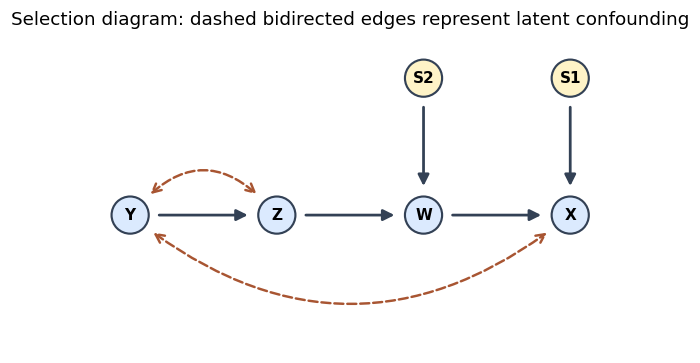

In [3]:
positions = {"Y": (0, 0), "Z": (1.5, 0), "W": (3, 0), "X": (4.5, 0),
             "S2": (3, 1.4), "S1": (4.5, 1.4)}
fig_graph, ax = plt.subplots(figsize=(10, 3.4))
for start, end in [("Y", "Z"), ("Z", "W"), ("W", "X"), ("S1", "X"), ("S2", "W")]:
    ax.add_patch(FancyArrowPatch(positions[start], positions[end], arrowstyle="-|>",
                                mutation_scale=15, shrinkA=19, shrinkB=19,
                                linewidth=1.8, color="#334155"))
for end, curvature in [("Z", -0.6), ("X", 0.4)]:
    ax.add_patch(FancyArrowPatch(positions["Y"], positions[end], arrowstyle="<->",
                                connectionstyle=f"arc3,rad={curvature}",
                                mutation_scale=14, shrinkA=19, shrinkB=19,
                                linestyle="--", linewidth=1.6, color="#a85532"))
for name, point in positions.items():
    selection = name.startswith("S")
    ax.add_patch(Circle(point, 0.19, facecolor="#fef3c7" if selection else "#dbeafe",
                        edgecolor="#334155", linewidth=1.4, zorder=3))
    ax.text(*point, name, ha="center", va="center", weight="bold", zorder=4)
ax.set(xlim=(-0.5, 5), ylim=(-1.4, 1.85), aspect="equal")
ax.axis("off")
ax.set_title("Selection diagram: dashed bidirected edges represent latent confounding")
fig_graph.tight_layout()
plt.show()

## 3. Run sID

`identify(...)` runs the selected mode and returns the transport formula. It does not derive causal weights or fit distributions. Printing the returned object produces only its LaTeX expression. Use display(formula), or leave formula as the final expression in a Jupyter cell, to render the mathematics.

In [4]:
formula = identify(
    SELECTION_DIAGRAM,
    outcomes=OUTCOMES,
    interventions=INTERVENTIONS,
    selection=SELECTION,
    mode=MODE,
)
print(formula)

P^{*}\left(X\mid\operatorname{do}(Y)\right) = \sum_{W,Y',Z,Z'}\left[P^{*}\left(X\mid W,Y',Z'\right)\,P^{*}\left(W\mid Y,Z\right)\,P^{*}\left(Y',Z'\right)\,P_{\mathrm{source}}\left(Z\mid \operatorname{do}(Y)\right)\right]


In [5]:
formula

TransportFormula(outcomes=('X',), interventions=('Y',), numerator=(Probability(variables=('X',), given=('W', "Y'", "Z'"), do=(), domain='target'), Probability(variables=('W',), given=('Y', 'Z'), do=(), domain='target'), Probability(variables=("Y'", "Z'"), given=(), do=(), domain='target'), Probability(variables=('Z',), given=(), do=('Y',), domain='source')), denominator=(), marginal=('W', "Y'", 'Z', "Z'"), aliases={"Y'": 'Y', "Z'": 'Z'}, provenance='user revised sID: standard')

### Display and inspect the returned formula

The formula object provides its own LaTeX display; no notebook-specific renderer is needed. Marginalization is written using $\sum$ throughout. This is a notation convention; continuous variables still require integration when the formula is evaluated.

Primed variables such as $Y'$ and $Z'$ are bound marginalization symbols. They remain distinct from the free intervention variable $Y$ and the other bound variable $Z$.

In [6]:
display(formula)
print("Marginalization variables:", formula.marginal)
print("Bound-symbol aliases:", formula.aliases)
print("Provenance:", formula.provenance)

rows = ["| Position | Domain | Factor |", "|---|---|---|"]
for position, factors in (("Numerator", formula.numerator), ("Denominator", formula.denominator)):
    for factor in factors:
        rows.append(f"| {position} | {factor.domain} | {str(factor).replace('|', '&#124;')} |")
display(Markdown("\n".join(rows)))

source_factors = sorted({
    str(p.mapped(formula.aliases))
    for p in formula.numerator + formula.denominator if p.domain == "source"
})
print("Source interventional factors appearing in this formula:")
for factor in source_factors:
    print(" -", factor)

TransportFormula(outcomes=('X',), interventions=('Y',), numerator=(Probability(variables=('X',), given=('W', "Y'", "Z'"), do=(), domain='target'), Probability(variables=('W',), given=('Y', 'Z'), do=(), domain='target'), Probability(variables=("Y'", "Z'"), given=(), do=(), domain='target'), Probability(variables=('Z',), given=(), do=('Y',), domain='source')), denominator=(), marginal=('W', "Y'", 'Z', "Z'"), aliases={"Y'": 'Y', "Z'": 'Z'}, provenance='user revised sID: standard')

Marginalization variables: ('W', "Y'", 'Z', "Z'")
Bound-symbol aliases: {"Y'": 'Y', "Z'": 'Z'}
Provenance: user revised sID: standard


| Position | Domain | Factor |
|---|---|---|
| Numerator | target | P*(X &#124; W,Y',Z') |
| Numerator | target | P*(W &#124; Y,Z) |
| Numerator | target | P*(Y',Z') |
| Numerator | source | P_source(Z &#124; do(Y)) |

Source interventional factors appearing in this formula:
 - P_source(Z | do(Y))


## 4. Compare the two modes

`standard` follows the original decomposition order and tries direct transport at its usual stage. `more_do` tries direct transport earlier in each single-component subproblem, preferentially retaining source interventional expressions.

The modes can return the same formula. Both results for the classification diagram are shown below; changing the mode does not guarantee a shorter or different expression.

In [7]:
for mode in ("standard", "more_do"):
    identified = identify(
        SELECTION_DIAGRAM, outcomes=OUTCOMES, interventions=INTERVENTIONS,
        selection=SELECTION, mode=mode,
    )
    display(Markdown(f"**Classification diagram: {mode}**"))
    display(identified)

**Classification diagram: standard**

TransportFormula(outcomes=('X',), interventions=('Y',), numerator=(Probability(variables=('X',), given=('W', "Y'", "Z'"), do=(), domain='target'), Probability(variables=('W',), given=('Y', 'Z'), do=(), domain='target'), Probability(variables=("Y'", "Z'"), given=(), do=(), domain='target'), Probability(variables=('Z',), given=(), do=('Y',), domain='source')), denominator=(), marginal=('W', "Y'", 'Z', "Z'"), aliases={"Y'": 'Y', "Z'": 'Z'}, provenance='user revised sID: standard')

**Classification diagram: more_do**

TransportFormula(outcomes=('X',), interventions=('Y',), numerator=(Probability(variables=('X',), given=('W', "Y'", "Z'"), do=(), domain='target'), Probability(variables=('W',), given=('Y', 'Z'), do=(), domain='target'), Probability(variables=("Y'", "Z'"), given=(), do=(), domain='target'), Probability(variables=('Z',), given=(), do=('Y',), domain='source')), denominator=(), marginal=('W', "Y'", 'Z', "Z'"), aliases={"Y'": 'Y', "Z'": 'Z'}, provenance='user revised sID: more_do')

### A small graph where the modes differ

Consider $S\to Y\to X$, with no latent confounding. The target effect is identifiable as $P^*(X\mid Y)$. Direct transport is also available because intervening on $Y$ blocks the influence of $S$ on $X$.

In this example, `standard` uses target observations while `more_do` returns a source interventional factor. The latter representation requires source causal knowledge if evaluated numerically.

In [8]:
SIMPLE_DIAGRAM = "Y; X; S; Y -> X; S -> Y;"

for mode in ("standard", "more_do"):
    identified = identify(
        SIMPLE_DIAGRAM, outcomes="X", interventions="Y", selection="S", mode=mode,
    )
    display(Markdown(f"**Simple diagram: {mode}**"))
    display(identified)
    print(identified)

**Simple diagram: standard**

TransportFormula(outcomes=('X',), interventions=('Y',), numerator=(Probability(variables=('X',), given=('Y',), do=(), domain='target'),), denominator=(), marginal=(), aliases={}, provenance='user revised sID: standard')

P^{*}\left(X\mid\operatorname{do}(Y)\right) = P^{*}\left(X\mid Y\right)


**Simple diagram: more_do**

TransportFormula(outcomes=('X',), interventions=('Y',), numerator=(Probability(variables=('X',), given=(), do=('Y',), domain='source'),), denominator=(), marginal=(), aliases={}, provenance='user revised sID: more_do')

P^{*}\left(X\mid\operatorname{do}(Y)\right) = P_{\mathrm{source}}\left(X\mid \operatorname{do}(Y)\right)


## 5. Handle an unsuccessful identification query

Now use $Y\to X$, $Y\leftrightarrow X$, and $S\to X$. Confounding obstructs target-only identification, and the selection edge permits the outcome mechanism to change.

The public interface raises `NotTransportableError` when sID returns no formula. Catch that specific exception when processing multiple queries. Warnings from the underlying algorithm are preserved; not every unsuccessful query takes the fallback branch that emits a warning.

In [9]:
UNSUCCESSFUL_DIAGRAM = "Y; X; S; Y -> X; Y <-> X; S -> X;"

with warnings.catch_warnings(record=True) as recorded:
    warnings.simplefilter("always")
    try:
        identify(
            UNSUCCESSFUL_DIAGRAM, outcomes="X", interventions="Y",
            selection="S", mode=MODE,
        )
    except NotTransportableError as error:
        print(f"Identification failed as expected: {error}")
    else:
        raise AssertionError("This example should not produce a transport formula.")

for warning in recorded:
    print(f"{warning.category.__name__}: {warning.message}")

Identification failed as expected: sID did not identify a transport formula.


## 6. Use your own graph

Edit `SELECTION_DIAGRAM`, `OUTCOMES`, `INTERVENTIONS`, `SELECTION`, and `MODE` in Section 2, then rerun Sections 2-3. The diagram illustration is a fixed drawing of the classification example; update its positions and edges if you change the graph.

Use tuples for multiple variables and `selection=()` for a graph without selection nodes. Every query variable must be declared in the graph, and selection nodes cannot have incoming or bidirected edges.

For a script, the essential call is:

```python
from tcb import identify

formula = identify(
    graph,
    outcomes=("X",),
    interventions=("Y",),
    selection=("S1", "S2"),
    mode="standard",
)
print(formula)
```

The result describes a functional of source and target distributions under the supplied graph assumptions. Numerical evaluation requires the distributions appearing in that formula.

Continue with [the synthetic classification notebook](Demo01_nonident_tcb_synthetic_classification.ipynb) for density estimation, causal weights, resampling, and evaluation. See [the package README](../README.md) for the full API.